In [1]:
import sys
!{sys.executable} -m pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/shauryalikhi/DS/.venv/bin/python -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

In [3]:
start = datetime.datetime(2006,1,1)
end = datetime.datetime(2016,1,1)

In [4]:
lst = ['BAC','C','GS','JPM','MS','WFC']
bank_stocks = yf.download(lst, start, end)

[*********************100%***********************]  6 of 6 completed


In [5]:
bank_stocks.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2517 entries, 2006-01-03 to 2015-12-31
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BAC)   2517 non-null   float64
 1   (Close, C)     2517 non-null   float64
 2   (Close, GS)    2517 non-null   float64
 3   (Close, JPM)   2517 non-null   float64
 4   (Close, MS)    2517 non-null   float64
 5   (Close, WFC)   2517 non-null   float64
 6   (High, BAC)    2517 non-null   float64
 7   (High, C)      2517 non-null   float64
 8   (High, GS)     2517 non-null   float64
 9   (High, JPM)    2517 non-null   float64
 10  (High, MS)     2517 non-null   float64
 11  (High, WFC)    2517 non-null   float64
 12  (Low, BAC)     2517 non-null   float64
 13  (Low, C)       2517 non-null   float64
 14  (Low, GS)      2517 non-null   float64
 15  (Low, JPM)     2517 non-null   float64
 16  (Low, MS)      2517 non-null   float64
 17  (Low, WFC)     2517 non-null   float64
 18  (

In [6]:
bank_stocks.head()

Price           Close                                                          \
Ticker            BAC           C         GS        JPM         MS        WFC   
Date                                                                            
2006-01-03  30.487946  315.803680  93.359016  23.633675  31.349623  18.379141   
2006-01-04  30.164146  309.973145  92.069489  23.497280  31.371122  18.165968   
2006-01-05  30.203007  311.510803  92.033287  23.568449  31.457155  18.145803   
2006-01-06  30.157660  311.510803  93.337296  23.734512  31.489424  18.252392   
2006-01-09  30.177103  310.037170  94.460152  24.119997  31.822742  18.249512   

Price            High                                    ...       Open  \
Ticker            BAC           C         GS        JPM  ...         GS   
Date                                                     ...              
2006-01-03  30.552702  316.380311  93.771954  23.733644  ...  91.786976   
2006-01-04  30.591547  314.586229  93.387981  23.805675  ...  92.257845   
2006-01-05  30.326048  312.535916  92.236130  23.609963  ...  91.279865   
2006-01-06  30.377836  313.304770  93.634320  23.864988  ...  92.214411   
2006-01-09  30.416708  312.279638  94.626771  24.149652  ...  93.090954   

Price                                          Volume                    \
Ticker            JPM         MS        WFC       BAC        C       GS   
Date                                                                      
2006-01-03  23.421979  30.736715  18.206297  16296700  1537600  6188700   
2006-01-04  23.592171  31.559297  18.321527  17757900  1870960  4861600   
2006-01-05  23.491350  31.478661  18.148684  14970700  1143160  3717400   
2006-01-06  23.675204  31.596952  18.194777  12599800  1370210  4319600   
2006-01-09  23.651477  31.521667  18.249512  15619400  1680740  4723500   

Price                                    
Ticker           JPM       MS       WFC  
Date                                     
2006-01-03  12838600  5377000  11016400  
2006-01-04  13491500  7977800  10870000  
2006-01-05   8109400  5778000  10158000  
2006-01-06   7966900  6889800   8403800  
2006-01-09  16575200  4144500   5619600  

[5 rows x 30 columns]

In [7]:
bank_stocks.columns = bank_stocks.columns.swaplevel(0,1)
bank_stocks.sort_index(axis=1,inplace=True)

In [8]:
bank_stocks.head()

Ticker            BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Date                                                                           
2006-01-03  30.487946  30.552702  29.885698  30.384331  16296700  315.803680   
2006-01-04  30.164146  30.591547  30.079961  30.436128  17757900  309.973145   
2006-01-05  30.203007  30.326048  29.995782  30.164154  14970700  311.510803   
2006-01-06  30.157660  30.377836  30.015192  30.306602  12599800  311.510803   
2006-01-09  30.177103  30.416708  30.021686  30.254814  15619400  310.037170   

Ticker                                                   ...         MS  \
Price             High         Low        Open   Volume  ...      Close   
Date                                                     ...              
2006-01-03  316.380311  308.243365  313.945639  1537600  ...  31.349623   
2006-01-04  314.586229  309.780941  313.048541  1870960  ...  31.371122   
2006-01-05  312.535916  310.101244  310.357522  1143160  ...  31.457155   
2006-01-06  313.304770  308.819834  313.176621  1370210  ...  31.489424   
2006-01-09  312.279638  309.460540  311.382655  1680740  ...  31.822742   

Ticker                                                      WFC             \
Price            High        Low       Open   Volume      Close       High   
Date                                                                         
2006-01-03  31.446398  30.505533  30.736715  5377000  18.379141  18.422352   
2006-01-04  31.871125  31.371122  31.559297  7977800  18.165968  18.333050   
2006-01-05  31.500167  31.193714  31.478661  5778000  18.145803  18.180372   
2006-01-06  31.639962  31.209852  31.596952  6889800  18.252392  18.307126   
2006-01-09  31.876507  31.516289  31.521667  4144500  18.249512  18.335935   

Ticker                                      
Price             Low       Open    Volume  
Date                                        
2006-01-03  17.972956  18.206297  11016400  
2006-01-04  18.070903  18.321527  10870000  
2006-01-05  18.039215  18.148684  10158000  
2006-01-06  18.082428  18.194777   8403800  
2006-01-09  18.180374  18.249512   5619600  

[5 rows x 30 columns]

In [9]:
bank_stocks.xs(key='Close',axis=1,level=1).max()

Ticker
BAC     36.870281
C      376.505219
GS     182.299454
JPM     52.581131
MS      49.144009
WFC     43.327560
dtype: float64

In [10]:
returns = bank_stocks.copy()

In [11]:
returns.head()

Ticker            BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Date                                                                           
2006-01-03  30.487946  30.552702  29.885698  30.384331  16296700  315.803680   
2006-01-04  30.164146  30.591547  30.079961  30.436128  17757900  309.973145   
2006-01-05  30.203007  30.326048  29.995782  30.164154  14970700  311.510803   
2006-01-06  30.157660  30.377836  30.015192  30.306602  12599800  311.510803   
2006-01-09  30.177103  30.416708  30.021686  30.254814  15619400  310.037170   

Ticker                                                   ...         MS  \
Price             High         Low        Open   Volume  ...      Close   
Date                                                     ...              
2006-01-03  316.380311  308.243365  313.945639  1537600  ...  31.349623   
2006-01-04  314.586229  309.780941  313.048541  1870960  ...  31.371122   
2006-01-05  312.535916  310.101244  310.357522  1143160  ...  31.457155   
2006-01-06  313.304770  308.819834  313.176621  1370210  ...  31.489424   
2006-01-09  312.279638  309.460540  311.382655  1680740  ...  31.822742   

Ticker                                                      WFC             \
Price            High        Low       Open   Volume      Close       High   
Date                                                                         
2006-01-03  31.446398  30.505533  30.736715  5377000  18.379141  18.422352   
2006-01-04  31.871125  31.371122  31.559297  7977800  18.165968  18.333050   
2006-01-05  31.500167  31.193714  31.478661  5778000  18.145803  18.180372   
2006-01-06  31.639962  31.209852  31.596952  6889800  18.252392  18.307126   
2006-01-09  31.876507  31.516289  31.521667  4144500  18.249512  18.335935   

Ticker                                      
Price             Low       Open    Volume  
Date                                        
2006-01-03  17.972956  18.206297  11016400  
2006-01-04  18.070903  18.321527  10870000  
2006-01-05  18.039215  18.148684  10158000  
2006-01-06  18.082428  18.194777   8403800  
2006-01-09  18.180374  18.249512   5619600  

[5 rows x 30 columns]

In [12]:
close = bank_stocks.xs('Close',1,1)
r = close.pct_change()

In [13]:
r.head()

Ticker,BAC,C,GS,JPM,MS,WFC
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018463,-0.013813,-0.005771,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005874
2006-01-09,0.000645,-0.004731,0.012030,0.016242,0.010585,-0.000158


In [14]:
r.columns = pd.MultiIndex.from_product([r.columns,['Return']])

In [15]:
r.head()

Ticker,BAC,C,GS,JPM,MS,WFC
,Return,Return,Return,Return,Return,Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018463,-0.013813,-0.005771,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005874
2006-01-09,0.000645,-0.004731,0.012030,0.016242,0.010585,-0.000158


In [16]:
returns = pd.concat([returns,r],axis=1)

In [17]:
returns = returns.sort_index(axis=1)

In [18]:
returns.head()

Ticker            BAC                                                       \
                Close       High        Low       Open    Return    Volume   
Date                                                                         
2006-01-03  30.487946  30.552702  29.885698  30.384331       NaN  16296700   
2006-01-04  30.164146  30.591547  30.079961  30.436128 -0.010621  17757900   
2006-01-05  30.203007  30.326048  29.995782  30.164154  0.001288  14970700   
2006-01-06  30.157660  30.377836  30.015192  30.306602 -0.001501  12599800   
2006-01-09  30.177103  30.416708  30.021686  30.254814  0.000645  15619400   

Ticker               C                                      ...         MS  \
                 Close        High         Low        Open  ...        Low   
Date                                                        ...              
2006-01-03  315.803680  316.380311  308.243365  313.945639  ...  30.505533   
2006-01-04  309.973145  314.586229  309.780941  313.048541  ...  31.371122   
2006-01-05  311.510803  312.535916  310.101244  310.357522  ...  31.193714   
2006-01-06  311.510803  313.304770  308.819834  313.176621  ...  31.209852   
2006-01-09  310.037170  312.279638  309.460540  311.382655  ...  31.516289   

Ticker                                          WFC                        \
                 Open    Return   Volume      Close       High        Low   
Date                                                                        
2006-01-03  30.736715       NaN  5377000  18.379141  18.422352  17.972956   
2006-01-04  31.559297  0.000686  7977800  18.165968  18.333050  18.070903   
2006-01-05  31.478661  0.002742  5778000  18.145803  18.180372  18.039215   
2006-01-06  31.596952  0.001026  6889800  18.252392  18.307126  18.082428   
2006-01-09  31.521667  0.010585  4144500  18.249512  18.335935  18.180374   

Ticker                                     
                 Open    Return    Volume  
Date                                       
2006-01-03  18.206297       NaN  11016400  
2006-01-04  18.321527 -0.011599  10870000  
2006-01-05  18.148684 -0.001110  10158000  
2006-01-06  18.194777  0.005874   8403800  
2006-01-09  18.249512 -0.000158   5619600  

[5 rows x 36 columns]

In [19]:
import seaborn as sns

<Axes: xlabel='Ticker-None', ylabel='Ticker-None'>

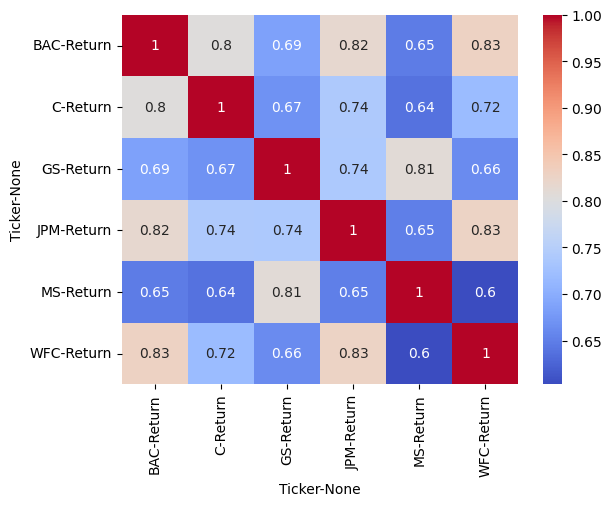

In [21]:
sns.heatmap(r.corr(), annot=True, cmap='coolwarm')

In [23]:
r.idxmin()
#Info regarding worst day: https://www.theguardian.com/business/2009/jan/20/stock-market-drop-obama-inauguration

Ticker        
BAC     Return   2009-01-20
C       Return   2009-02-27
GS      Return   2009-01-20
JPM     Return   2009-01-20
MS      Return   2008-10-09
WFC     Return   2009-01-20
dtype: datetime64[s]

In [24]:
r.idxmax()

Ticker        
BAC     Return   2009-04-09
C       Return   2008-11-24
GS      Return   2008-11-24
JPM     Return   2009-01-21
MS      Return   2008-10-13
WFC     Return   2008-07-16
dtype: datetime64[s]

In [26]:
#We can see Citibank was the worst stock to invest in due to it having the highest standard deviation.
r.std().idxmax()

('C', 'Return')

In [29]:
r.head()

Ticker,BAC,C,GS,JPM,MS,WFC
,Return,Return,Return,Return,Return,Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010621,-0.018463,-0.013813,-0.005771,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003029,0.002742,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001026,0.005874
2006-01-09,0.000645,-0.004731,0.012030,0.016242,0.010585,-0.000158


<Axes: xlabel='Return', ylabel='Count'>

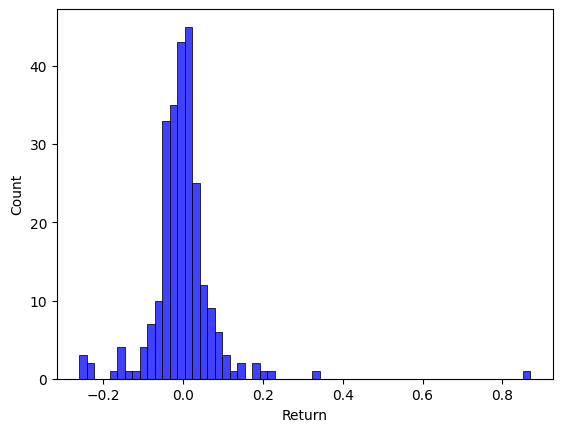

In [42]:
ms_returns_2008 = r['MS']['Return']['2008-01-01':'2008-12-31']
sns.histplot(ms_returns_2008,color='blue',bins=60)

<Axes: xlabel='Return', ylabel='Count'>

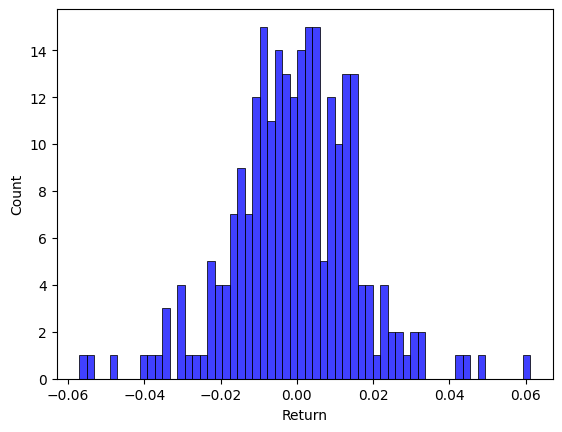

In [43]:
ms_returns_2015 = r['MS']['Return']['2015-01-01':'2015-12-31']
sns.histplot(ms_returns_2015,color='blue',bins=60)